In [ ]:
import pandas as pd
df = pd.read_csv('../data/raw/your_file.csv')
df.head()

In [ ]:
import pandas as pd
df = pd.read_csv('../data/raw/online+retail+i')
df.head()

In [ ]:
import os

os.listdir('../data/raw')

In [ ]:
import os
os.listdir('../data/raw')

In [ ]:
import os
files = os.listdir('../data/raw/online+retail+ii')
print(files)

In [ ]:
import pandas as pd

df = pd.read_excel('../data/raw/online+retail+ii/online_retail_II.xlsx')
df.head()

In [ ]:
df.shape
df.columns
df.head()

In [ ]:
df.shape
df.columns
df.head()

In [ ]:
df.info()
df.isnull().sum()

In [ ]:
df = df.dropna(subset=['Customer ID'])

In [ ]:
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [ ]:
df = df.drop_duplicates()

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
df['Revenue'] = df['Quantity'] * df['Price']

In [ ]:
df.describe()

In [ ]:
df['Revenue'].sum()

In [ ]:
df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

In [ ]:
df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

In [ ]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales.plot(figsize=(10,5))

In [ ]:
df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False).head(10)

In [ ]:
import pandas as pd
import sqlite3

# Load your clean data
df = pd.read_csv('data/processed/clean_retail.csv', 
                  parse_dates=['InvoiceDate'])

# Create SQLite database (creates file automatically)
conn = sqlite3.connect('data/processed/retail.db')

# Push dataframe into SQL table
df.to_sql('retail_sales', conn, 
           if_exists='replace',   # replace if already exists
           index=False)

print("✅ Data loaded into SQLite!")
print(f"Total rows in DB: {pd.read_sql('SELECT COUNT(*) FROM retail_sales', conn).iloc[0,0]:,}")

conn.close()

In [ ]:
import os

# Run this to see where Python is currently looking
print("Current folder:", os.getcwd())

# See what files/folders exist here
print("\nFolders & files here:")
for item in os.listdir('.'):
    print(" ", item)

In [ ]:
import os

# Go up one level from notebooks/ → project root
os.chdir('..')

# Confirm it worked
print("Current folder:", os.getcwd())
print("Folders here:", os.listdir('.'))

In [ ]:
import pandas as pd
import os

# Create folders if missing
os.makedirs('data/raw',       exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('visuals/charts', exist_ok=True)
os.makedirs('sql',            exist_ok=True)
print("✅ Folders ready")

# ⚠️ Put your actual Excel filename here
RAW_FILE = 'data/raw/online_retail_II.xlsx'

df = pd.read_excel(RAW_FILE, sheet_name='Year 2010-2011')
print(f"✅ Raw data loaded: {df.shape}")

# Clean
df = df.drop_duplicates()
df = df.dropna(subset=['Customer ID'])
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)
df['Revenue']     = df['Quantity'] * df['Price']
df['Year']        = df['InvoiceDate'].dt.year
df['Month']       = df['InvoiceDate'].dt.month
df['Month_Name']  = df['InvoiceDate'].dt.strftime('%b')
df['DayOfWeek']   = df['InvoiceDate'].dt.day_name()
df['Hour']        = df['InvoiceDate'].dt.hour

# Save
df.to_csv('data/processed/clean_retail.csv', index=False)
print(f"✅ Saved!  Shape: {df.shape}")
print(f"   Revenue total: £{df['Revenue'].sum():,.2f}")

In [ ]:
import os

print("📁 data/raw/ contains:")
print(os.listdir('data/raw'))

print("\n📁 data/processed/ contains:")
print(os.listdir('data/processed'))

In [ ]:
import os

# Look inside the downloaded folder
inner_path = 'data/raw/online+retail+ii'

print("📁 Inside online+retail+ii:")
for item in os.listdir(inner_path):
    print(" ", item)

In [ ]:
import pandas as pd
import os

# ── Correct path (file is inside the subfolder) ──
RAW_FILE = 'data/raw/online+retail+ii/online_retail_II.xlsx'

print("File found:", os.path.exists(RAW_FILE))

# ── Load ──────────────────────────────────────
df = pd.read_excel(RAW_FILE, sheet_name='Year 2010-2011')
print(f"✅ Loaded: {df.shape}")

# ── Clean ─────────────────────────────────────
df = df.drop_duplicates()
df = df.dropna(subset=['Customer ID'])
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)
df['Revenue']     = df['Quantity'] * df['Price']
df['Year']        = df['InvoiceDate'].dt.year
df['Month']       = df['InvoiceDate'].dt.month
df['Month_Name']  = df['InvoiceDate'].dt.strftime('%b')
df['DayOfWeek']   = df['InvoiceDate'].dt.day_name()
df['Hour']        = df['InvoiceDate'].dt.hour

# ── Save ──────────────────────────────────────
df.to_csv('data/processed/clean_retail.csv', index=False)
print(f"✅ Clean data saved!")
print(f"   Shape      : {df.shape}")
print(f"   Revenue    : £{df['Revenue'].sum():,.2f}")
print(f"   Customers  : {df['Customer ID'].nunique():,}")
print(f"   Date range : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")

In [ ]:
import pandas as pd
import os

RAW_FILE = 'data/raw/online+retail+ii/online_retail_II.xlsx'

# ── Load (takes 1-2 mins, be patient) ────────
print("⏳ Loading Excel file... please wait")
df = pd.read_excel(RAW_FILE, sheet_name='Year 2010-2011')
print(f"✅ Loaded: {df.shape}")

# ── Clean ─────────────────────────────────────
print("⏳ Cleaning data...")

df = df.drop_duplicates()
df = df.dropna(subset=['Customer ID'])
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype(int).astype(str)
df['Revenue']     = df['Quantity'] * df['Price']
df['Year']        = df['InvoiceDate'].dt.year
df['Month']       = df['InvoiceDate'].dt.month
df['Month_Name']  = df['InvoiceDate'].dt.strftime('%b')
df['DayOfWeek']   = df['InvoiceDate'].dt.day_name()
df['Hour']        = df['InvoiceDate'].dt.hour

# ── Save ──────────────────────────────────────
df.to_csv('data/processed/clean_retail.csv', index=False)

# ── Final Report ──────────────────────────────
print("\n" + "="*45)
print("  ✅ DATA CLEANING COMPLETE")
print("="*45)
print(f"  Shape       : {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"  Revenue     : £{df['Revenue'].sum():,.2f}")
print(f"  Customers   : {df['Customer ID'].nunique():,}")
print(f"  Products    : {df['StockCode'].nunique():,}")
print(f"  Countries   : {df['Country'].nunique():,}")
print(f"  Date range  : {df['InvoiceDate'].min().date()}")
print(f"              → {df['InvoiceDate'].max().date()}")
print("="*45)
print("\n✅ Saved → data/processed/clean_retail.csv")

In [ ]:
import pandas as pd
import sqlite3
import os

# Load clean data
df = pd.read_csv('data/processed/clean_retail.csv',
                  parse_dates=['InvoiceDate'])

# Create database
conn = sqlite3.connect('data/processed/retail.db')

# Push to SQL table
df.to_sql('retail_sales', conn,
           if_exists='replace',
           index=False)

# Verify
count = pd.read_sql('SELECT COUNT(*) as total FROM retail_sales', conn)
print("✅ SQLite DB created!")
print(f"   Rows in DB : {count['total'][0]:,}")
print(f"   DB saved   : data/processed/retail.db")

In [ ]:
# Reusable query runner — use this for ALL queries
def run_query(sql, title=""):
    result = pd.read_sql(sql, conn)
    if title:
        print(f"\n{'='*50}")
        print(f"  {title}")
        print(f"{'='*50}")
    print(result.to_string(index=False))
    return result

In [ ]:
q1 = """
SELECT 
    strftime('%Y-%m', InvoiceDate)      AS Month,
    ROUND(SUM(Revenue), 2)              AS Total_Revenue,
    COUNT(DISTINCT Invoice)             AS Total_Orders,
    COUNT(DISTINCT "Customer ID")       AS Unique_Customers,
    ROUND(SUM(Revenue) / 
          COUNT(DISTINCT Invoice), 2)   AS Avg_Order_Value
FROM retail_sales
GROUP BY Month
ORDER BY Month;
"""
monthly = run_query(q1, "Query 1 → Monthly Revenue")

In [ ]:
q2 = """
SELECT 
    "Customer ID"                       AS Customer_ID,
    COUNT(DISTINCT Invoice)             AS Total_Orders,
    ROUND(SUM(Revenue), 2)              AS Total_Revenue,
    ROUND(AVG(Revenue), 2)              AS Avg_Order_Value,
    MIN(DATE(InvoiceDate))              AS First_Purchase,
    MAX(DATE(InvoiceDate))              AS Last_Purchase
FROM retail_sales
GROUP BY "Customer ID"
ORDER BY Total_Revenue DESC
LIMIT 10;
"""
top_customers = run_query(q2, "Query 2 → Top 10 Customers (VIPs)")

In [ ]:
q3 = """
SELECT 
    CASE 
        WHEN order_count = 1 THEN '1. One-Time Buyer'
        WHEN order_count BETWEEN 2 AND 5 THEN '2. Occasional Buyer'
        ELSE '3. Loyal Customer'
    END                                 AS Customer_Type,
    COUNT(*)                            AS Customer_Count,
    ROUND(COUNT(*) * 100.0 / 
          SUM(COUNT(*)) OVER(), 2)      AS Percentage
FROM (
    SELECT 
        "Customer ID",
        COUNT(DISTINCT Invoice)         AS order_count
    FROM retail_sales
    GROUP BY "Customer ID"
) t
GROUP BY Customer_Type
ORDER BY Customer_Type;
"""
segments = run_query(q3, "Query 3 → Customer Loyalty Segments")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('data/processed/clean_retail.csv',
                  parse_dates=['InvoiceDate'])

# ── Reference date = day AFTER last transaction ──
# Think of it as "today" from the dataset's perspective
# This is how every real RFM model is built

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f"Last transaction : {df['InvoiceDate'].max().date()}")
print(f"Reference date   : {reference_date.date()}")
print("\n💡 Why +1 day?")
print("   So the most recent customer gets Recency=1, not 0")

In [ ]:
# ============================================
# CORE RFM CALCULATION
# ============================================

rfm = df.groupby('Customer ID').agg(
    
    # RECENCY: days since last purchase
    # Lower number = better (bought recently)
    Recency   = ('InvoiceDate', 
                  lambda x: (reference_date - x.max()).days),
    
    # FREQUENCY: number of unique invoices
    # Higher number = better (buys often)
    Frequency = ('Invoice', 'nunique'),
    
    # MONETARY: total revenue from customer
    # Higher number = better (spends more)
    Monetary  = ('Revenue', 'sum')

).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print("✅ RFM table created!")
print(f"   Customers : {len(rfm):,}")
print(f"\nSample (first 5 rows):")
print(rfm.head().to_string(index=False))

print(f"\nRFM Summary Stats:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

In [ ]:
# ============================================
# SCORING: Convert raw numbers → 1 to 5 score
# ============================================
# We use QUINTILES — split customers into 5 equal groups

# ── RECENCY score ─────────────────────────────
# LOWER recency = BETTER → so score is REVERSED
# (bought yesterday gets 5, bought a year ago gets 1)
rfm['R_Score'] = pd.qcut(rfm['Recency'],
                           q=5,
                           labels=[5, 4, 3, 2, 1])

# ── FREQUENCY score ───────────────────────────
# HIGHER frequency = BETTER → normal order
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                           q=5,
                           labels=[1, 2, 3, 4, 5])

# ── MONETARY score ────────────────────────────
# HIGHER monetary = BETTER → normal order
rfm['M_Score'] = pd.qcut(rfm['Monetary'],
                           q=5,
                           labels=[1, 2, 3, 4, 5])

# ── Convert to integers ───────────────────────
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# ── Combined RFM Score (string) ───────────────
# e.g. R=5, F=4, M=3 → "543"
rfm['RFM_Score'] = (rfm['R_Score'].astype(str) +
                     rfm['F_Score'].astype(str) +
                     rfm['M_Score'].astype(str))

# ── Total RFM Score (sum) ─────────────────────
rfm['RFM_Total'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print("✅ RFM Scores assigned!")
print(rfm[['Customer ID','Recency','Frequency','Monetary',
           'R_Score','F_Score','M_Score',
           'RFM_Score','RFM_Total']].head(10).to_string(index=False))

In [ ]:
# ============================================
# CUSTOMER SEGMENTATION — The Business Gold
# ============================================

def assign_segment(row):
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'           # Best customers — buy often, recently, spend most

    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'     # Consistent buyers, good value

    elif r >= 4 and f <= 2:
        return 'New Customers'       # Bought recently but not yet frequent

    elif r >= 3 and f >= 2 and m <= 2:
        return 'Potential Loyalists' # Recent + some frequency, low spend yet

    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'             # Used to buy well — now gone quiet 😟

    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cant Lose Them'      # Were champions, now inactive — URGENT

    elif r == 1 and f == 1 and m == 1:
        return 'Lost'                # Haven't bought in ages, low value

    else:
        return 'Hibernating'         # Low scores across the board

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# ── Segment Summary ───────────────────────────
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count = ('Customer ID', 'count'),
    Avg_Recency    = ('Recency',     'mean'),
    Avg_Frequency  = ('Frequency',   'mean'),
    Avg_Monetary   = ('Monetary',    'mean'),
    Total_Revenue  = ('Monetary',    'sum')
).round(2).reset_index()

segment_summary['Revenue_Share_%'] = (
    segment_summary['Total_Revenue'] /
    segment_summary['Total_Revenue'].sum() * 100
).round(2)

segment_summary = segment_summary.sort_values(
    'Total_Revenue', ascending=False)

print("✅ Customer Segments:")
print(segment_summary.to_string(index=False))

# Save RFM table
rfm.to_csv('data/processed/rfm_segments.csv', index=False)
print("\n✅ RFM saved → data/processed/rfm_segments.csv")

In [ ]:
# ============================================
# RFM VISUALIZATION — 3 key charts
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Chart 1: Customer count per segment ──────
colors = ['#2ecc71','#3498db','#9b59b6',
          '#f39c12','#e74c3c','#1abc9c',
          '#e67e22','#95a5a6']

seg_counts = rfm['Segment'].value_counts()
axes[0].barh(seg_counts.index, seg_counts.values,
             color=colors[:len(seg_counts)])
axes[0].set_title('Customers per Segment',
                   fontweight='bold', fontsize=13)
axes[0].set_xlabel('Customer Count')
for i, v in enumerate(seg_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# ── Chart 2: Revenue share per segment ───────
rev_share = rfm.groupby('Segment')['Monetary'].sum().sort_values()
axes[1].barh(rev_share.index, rev_share.values,
             color=colors[:len(rev_share)])
axes[1].set_title('Revenue by Segment',
                   fontweight='bold', fontsize=13)
axes[1].set_xlabel('Total Revenue (£)')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

# ── Chart 3: RFM Score Distribution ──────────
axes[2].hist(rfm['RFM_Total'], bins=12,
             color='steelblue', edgecolor='white',
             linewidth=0.8)
axes[2].set_title('RFM Total Score Distribution',
                   fontweight='bold', fontsize=13)
axes[2].set_xlabel('RFM Total Score (3–15)')
axes[2].set_ylabel('Number of Customers')
axes[2].axvline(rfm['RFM_Total'].mean(),
                color='red', linestyle='--',
                linewidth=1.5, label=f'Mean: {rfm["RFM_Total"].mean():.1f}')
axes[2].legend()

plt.suptitle('RFM Customer Segmentation Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('visuals/charts/05_rfm_segments.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ RFM chart saved!")

In [ ]:
# ============================================
# CELL 6 — Business Action Plan (IMPORTANT)
# Add this as output in your notebook
# ============================================

actions = {
    'Segment':             ['Champions', 'Loyal Customers', 
                            'At Risk', 'Hibernating',
                            'New Customers', 'Potential Loyalists',
                            'Lost'],

    'What This Means':     [
        'Best customers — recent, frequent, high spend',
        'Regular buyers, good lifetime value',
        'Were great customers, now going quiet',
        'Not bought in long time, low engagement',
        'Bought recently but only once',
        'Recent + some frequency, not spending much yet',
        'No activity, very low scores'
    ],

    'Business Action':     [
        'VIP rewards, early access, referral program',
        'Upsell premium products, loyalty points',
        'URGENT win-back email, special discount',
        'Re-engagement campaign, "We miss you" offer',
        'Onboarding email series, first review incentive',
        'Nurture with product recommendations',
        'Low priority — minimal spend on reactivation'
    ]
}

action_df = pd.DataFrame(actions)
print("="*80)
print("  BUSINESS ACTION PLAN BY RFM SEGMENT")
print("="*80)
print(action_df.to_string(index=False))
action_df.to_csv('data/processed/rfm_action_plan.csv', index=False)
print("\n✅ Action plan saved!")

In [ ]:
# ============================================
# CELL 7 — RFM Heatmap (Recruiter Favourite)
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Heatmap: Recency vs Frequency ─────────────
pivot = rfm.pivot_table(
    index='R_Score',
    columns='F_Score',
    values='Monetary',
    aggfunc='mean'
).round(0)

sns.heatmap(pivot,
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            ax=axes[0],
            linewidths=0.5,
            cbar_kws={'label': 'Avg Revenue (£)'})
axes[0].set_title('Avg Revenue by R Score vs F Score\n(Heatmap)',
                   fontweight='bold', fontsize=13)
axes[0].set_xlabel('Frequency Score →  (1=Low, 5=High)')
axes[0].set_ylabel('Recency Score →  (1=Old, 5=Recent)')

# ── Segment Revenue Share — Donut Chart ───────
seg_rev = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

wedge_props = {'linewidth': 2, 'edgecolor': 'white'}
colors = ['#2ecc71','#3498db','#9b59b6','#f39c12',
          '#e74c3c','#1abc9c','#e67e22','#95a5a6']

axes[1].pie(seg_rev.values,
            labels=seg_rev.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=140,
            wedgeprops=wedge_props,
            pctdistance=0.82)

# Make it a donut
centre_circle = plt.Circle((0, 0), 0.60,
                             fc='white', linewidth=0)
axes[1].add_artist(centre_circle)
axes[1].set_title('Revenue Share by Segment\n(Donut Chart)',
                   fontweight='bold', fontsize=13)

plt.suptitle('RFM Deep Dive Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('visuals/charts/06_rfm_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved!")

In [ ]:
import os

# Just writes the file — does NOT run it
dashboard_code = open('src/dashboard.py', 'r').read() \
    if os.path.exists('src/dashboard.py') else None

if dashboard_code:
    print("✅ dashboard.py already exists at src/dashboard.py")
    print("✅ File is ready to run from terminal")
else:
    print("❌ File missing — tell me and I'll resend the write command")

print("\nFile location:", os.path.abspath('src/dashboard.py'))

In [ ]:
import os

# ── Step 1: Go to project root ────────────────
os.chdir('..')  # go up from notebooks/ → project root

print("Current folder:", os.getcwd())
print("Folders here:", os.listdir('.'))

In [ ]:
import os

# Make sure src/ exists
os.makedirs('src', exist_ok=True)

# Write dashboard.py
code = r"""
import streamlit as st
import pandas as pd
import plotly.express as px
import os

st.set_page_config(
    page_title="E-Commerce RFM Dashboard",
    page_icon="🛒",
    layout="wide"
)

@st.cache_data
def load_data():
    base = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
    df  = pd.read_csv(
        os.path.join(base, 'data', 'processed', 'clean_retail.csv'),
        parse_dates=['InvoiceDate']
    )
    rfm = pd.read_csv(
        os.path.join(base, 'data', 'processed', 'rfm_segments.csv')
    )
    return df, rfm

df, rfm = load_data()

# ── Sidebar ───────────────────────────────────
st.sidebar.title("🛒 RFM Dashboard")
st.sidebar.markdown("**E-Commerce Sales Analysis**")
st.sidebar.markdown("---")

all_segments = ['All'] + sorted(rfm['Segment'].unique().tolist())
selected_seg = st.sidebar.selectbox("Filter by Segment", all_segments)
rfm_filtered = rfm if selected_seg == 'All' \
               else rfm[rfm['Segment'] == selected_seg]

# ── Header ────────────────────────────────────
st.title("🛒 E-Commerce Sales & RFM Dashboard")
st.markdown("*Customer behavior, revenue trends and RFM segmentation*")
st.markdown("---")

# ── KPI Cards ─────────────────────────────────
st.subheader("📊 Key Business Metrics")
c1, c2, c3, c4, c5 = st.columns(5)
c1.metric("💰 Total Revenue",
          f"£{df['Revenue'].sum()/1e6:.2f}M")
c2.metric("👥 Customers",
          f"{df['Customer ID'].nunique():,}")
c3.metric("📦 Total Orders",
          f"{df['Invoice'].nunique():,}")
c4.metric("🛍️ Avg Order Value",
          f"£{df.groupby('Invoice')['Revenue'].sum().mean():.0f}")
c5.metric("🏆 Champions",
          f"{(rfm['Segment']=='Champions').sum():,}",
          f"{(rfm['Segment']=='Champions').sum()/len(rfm)*100:.1f}% of base")

st.markdown("---")

# ── Revenue Trend + Donut ─────────────────────
col_left, col_right = st.columns([3, 2])

with col_left:
    st.subheader("📈 Monthly Revenue Trend")
    monthly = (
        df.groupby(df['InvoiceDate'].dt.to_period('M'))['Revenue']
        .sum().reset_index()
    )
    monthly['InvoiceDate'] = monthly['InvoiceDate'].astype(str)
    fig_trend = px.area(
        monthly, x='InvoiceDate', y='Revenue',
        color_discrete_sequence=['#1f77b4'],
        labels={'Revenue':'Revenue (£)','InvoiceDate':'Month'}
    )
    fig_trend.update_layout(
        showlegend=False,
        yaxis_tickprefix='£',
        yaxis_tickformat=',.0f',
        margin=dict(l=0,r=0,t=10,b=0)
    )
    st.plotly_chart(fig_trend, use_container_width=True)

with col_right:
    st.subheader("🍩 Revenue by Segment")
    seg_rev = (
        rfm.groupby('Segment')['Monetary'].sum()
        .reset_index().sort_values('Monetary', ascending=False)
    )
    fig_donut = px.pie(
        seg_rev, values='Monetary', names='Segment',
        hole=0.55,
        color_discrete_sequence=px.colors.qualitative.Set2
    )
    fig_donut.update_layout(margin=dict(l=0,r=0,t=10,b=0))
    st.plotly_chart(fig_donut, use_container_width=True)

st.markdown("---")

# ── Heatmap + Segment Bar ─────────────────────
col_l, col_r = st.columns(2)

with col_l:
    st.subheader("🔥 RFM Heatmap")
    pivot = rfm.pivot_table(
        index='R_Score', columns='F_Score',
        values='Monetary', aggfunc='mean'
    ).round(0)
    fig_heat = px.imshow(
        pivot, color_continuous_scale='YlOrRd',
        labels=dict(x="Frequency Score",
                    y="Recency Score",
                    color="Avg Revenue £"),
        text_auto=True, aspect='auto'
    )
    fig_heat.update_layout(margin=dict(l=0,r=0,t=10,b=0))
    st.plotly_chart(fig_heat, use_container_width=True)

with col_r:
    st.subheader("👥 Customers per Segment")
    seg_count = (rfm_filtered['Segment']
                 .value_counts().reset_index())
    seg_count.columns = ['Segment', 'Count']
    fig_bar = px.bar(
        seg_count.sort_values('Count'),
        x='Count', y='Segment', orientation='h',
        color='Count', color_continuous_scale='Blues',
        text='Count'
    )
    fig_bar.update_layout(
        showlegend=False,
        coloraxis_showscale=False,
        margin=dict(l=0,r=0,t=10,b=0)
    )
    st.plotly_chart(fig_bar, use_container_width=True)

st.markdown("---")

# ── Top Products + Countries ──────────────────
col_p, col_c = st.columns(2)

with col_p:
    st.subheader("🏆 Top 10 Products")
    top_prod = (
        df.groupby('Description')['Revenue'].sum()
        .nlargest(10).reset_index().sort_values('Revenue')
    )
    fig_prod = px.bar(
        top_prod, x='Revenue', y='Description',
        orientation='h',
        color_discrete_sequence=['#2ecc71'],
        text=top_prod['Revenue'].apply(lambda x: f'£{x:,.0f}')
    )
    fig_prod.update_layout(
        margin=dict(l=0,r=0,t=10,b=0),
        yaxis_title=''
    )
    st.plotly_chart(fig_prod, use_container_width=True)

with col_c:
    st.subheader("🌍 Revenue by Country (excl. UK)")
    top_country = (
        df[df['Country'] != 'United Kingdom']
        .groupby('Country')['Revenue'].sum()
        .nlargest(10).reset_index().sort_values('Revenue')
    )
    fig_country = px.bar(
        top_country, x='Revenue', y='Country',
        orientation='h',
        color_discrete_sequence=['#e74c3c'],
        text=top_country['Revenue'].apply(lambda x: f'£{x:,.0f}')
    )
    fig_country.update_layout(
        margin=dict(l=0,r=0,t=10,b=0),
        yaxis_title=''
    )
    st.plotly_chart(fig_country, use_container_width=True)

st.markdown("---")

# ── RFM Table ─────────────────────────────────
st.subheader("📋 RFM Segment Detail Table")
display_cols = ['Customer ID','Recency','Frequency','Monetary',
                'R_Score','F_Score','M_Score','RFM_Total','Segment']
st.dataframe(
    rfm_filtered[display_cols]
    .sort_values('RFM_Total', ascending=False)
    .reset_index(drop=True),
    use_container_width=True,
    height=300
)
csv = rfm_filtered.to_csv(index=False)
st.download_button(
    "⬇️ Download RFM Data",
    csv, 'rfm_segments.csv', 'text/csv'
)
"""

# Write to correct location
with open('src/dashboard.py', 'w', encoding='utf-8') as f:
    f.write(code)

# Verify
print("✅ File created successfully!")
print(f"   Location : {os.path.abspath('src/dashboard.py')}")
print(f"   Size     : {os.path.getsize('src/dashboard.py')} bytes")

In [ ]:
import datetime as dt

latest_date = df['InvoiceDate'].max()

rfm['Days_Since_Last_Purchase'] = (latest_date - rfm['Recency']).dt.days

rfm['Churn_Risk'] = rfm['Days_Since_Last_Purchase'].apply(
    lambda x: 'High Risk' if x > 90 else 'Low Risk'
)

In [1]:
import pandas as pd

# Load data
df = pd.read_excel('../data/raw/online+retail+ii/online_retail_II.xlsx')

# Clean data
df = df.dropna(subset=['Customer ID'])
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df = df.drop_duplicates()

# Fix date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create revenue
df['Revenue'] = df['Quantity'] * df['Price']

# Check
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [2]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (df['InvoiceDate'].max() - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,164,11,372.86
1,12347.0,2,2,1323.32
2,12348.0,73,1,222.16
3,12349.0,42,3,2671.14
4,12351.0,10,1,300.93


In [3]:
rfm['Days_Since_Last_Purchase'] = rfm['Recency']

rfm['Churn_Risk'] = rfm['Days_Since_Last_Purchase'].apply(
    lambda x: 'High Risk' if x > 90 else 'Low Risk'
)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Days_Since_Last_Purchase,Churn_Risk
0,12346.0,164,11,372.86,164,High Risk
1,12347.0,2,2,1323.32,2,Low Risk
2,12348.0,73,1,222.16,73,Low Risk
3,12349.0,42,3,2671.14,42,Low Risk
4,12351.0,10,1,300.93,10,Low Risk


In [4]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary,Days_Since_Last_Purchase
count,4312.000000,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,90.171846,4.455705,2040.406712,90.171846
std,1701.200176,96.860633,8.170213,8911.755977,96.860633
min,12346.000000,0.000000,1.000000,2.950000,0.000000
25%,13882.500000,17.000000,1.000000,307.187500,17.000000
50%,15350.500000,52.000000,2.000000,701.615000,52.000000
75%,16834.250000,135.000000,5.000000,1714.932500,135.000000
max,18287.000000,373.000000,205.000000,349164.350000,373.000000


In [5]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])

In [6]:
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])

In [7]:
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

In [8]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Days_Since_Last_Purchase,Churn_Risk,R_score,F_score,M_score
0,12346.0,164,11,372.86,164,High Risk,1,4,2
1,12347.0,2,2,1323.32,2,Low Risk,4,2,3
2,12348.0,73,1,222.16,73,Low Risk,2,1,1
3,12349.0,42,3,2671.14,42,Low Risk,3,3,4
4,12351.0,10,1,300.93,10,Low Risk,4,1,1


In [9]:
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [10]:
def segment_customer(row):
    if row['R_score'] == 4 and row['F_score'] == 4:
        return 'VIP Customers'
    elif row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] <= 2:
        return 'At Risk Customers'
    else:
        return 'Regular Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [11]:
rfm['Segment'].value_counts()

Segment
Loyal Customers      1569
At Risk Customers    1437
Regular Customers     719
VIP Customers         587
Name: count, dtype: int64

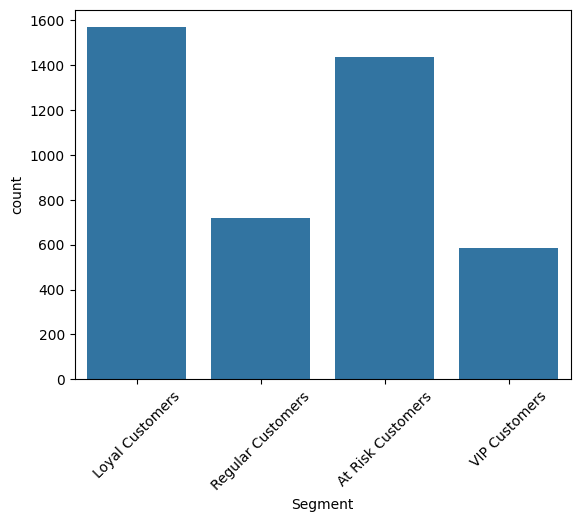

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=rfm, x='Segment')
plt.xticks(rotation=45)
plt.show()

In [13]:
rfm[rfm['Segment'] == 'VIP Customers'].sort_values(by='Monetary', ascending=False).head()

,Customer ID,Recency,Frequency,Monetary,Days_Since_Last_Purchase,Churn_Risk,R_score,F_score,M_score,RFM_Score,Segment
4183,18102.0,0,89,349164.35,0,Low Risk,4,4,4,444,VIP Customers
1637,14646.0,9,78,248396.50,9,Low Risk,4,4,4,444,VIP Customers
1269,14156.0,6,102,196549.74,6,Low Risk,4,4,4,444,VIP Customers
1840,14911.0,0,205,152121.22,0,Low Risk,4,4,4,444,VIP Customers
939,13694.0,8,94,131443.19,8,Low Risk,4,4,4,444,VIP Customers


In [14]:
rfm.to_csv('../data/processed/rfm_data.csv', index=False)